<a href="https://colab.research.google.com/github/norayyh/AutoInsight-R/blob/main/autoinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install anthropic pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.6/700.6 kB 9.7 MB/s eta 0:00:00


In [3]:
# Upload datasets to Colab from GitHub
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/Iris.csv -O Iris.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/titanic.csv -O titanic.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/housing.csv -O housing.csv
print("Datasets downloaded successfully")

Datasets downloaded successfully


In [4]:
# Install the Anthropic library
import anthropic
from google.colab import userdata

# Initialize the client using the secret API key
client = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))

# Send a test request to verify the API connection
response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Write Python code using pandas to read iris.csv and print the first 5 rows"}
    ]
)

print(response.content[0].text)

## Reading Iris Dataset with Pandas

```python
import pandas as pd

# Read the iris.csv file
df = pd.read_csv('iris.csv')

# Print the first 5 rows
print(df.head())
```

### Output (Example)
```
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
```

### Alternative: Load directly from seaborn (if you don't have the CSV)

```python
import pandas as pd
import seaborn as sns

# Load iris dataset and save as CSV
df = sns.load_dataset('iris')
df.to_csv('iris.csv', index=False)

# Read and print first 5 rows
df = pd.read_csv('iris.csv')
print(df.head())
```

### Key Methods Used

| Method | Description |
|--------|-------------|
| `pd.read_csv()` | Reads a CSV fil

In [5]:
import traceback

def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()

# Test the executor with a simple example
test_code = "print('Executor is working!')"
success, message = execute_code(test_code)
print(message)

Executor is working!
Code executed successfully


In [6]:
import re
import pandas as pd
import traceback

def clean_code(code: str) -> str:
    """
    Remove markdown code block formatting from generated code.
    """
    code = re.sub(r"```python\n", "", code)
    code = re.sub(r"```", "", code)
    return code.strip()


def diagnose_error(error_message: str, dataset_path: str) -> str:
    """
    Diagnose the error type and return additional context for repair.
    """
    extra_context = ""

    try:
        df = pd.read_csv(dataset_path)

        if "KeyError" in error_message or "Column not found" in error_message:
            extra_context = f"Actual column names are: {df.columns.tolist()}"

        elif "FileNotFoundError" in error_message:
            extra_context = f"The correct file path is: {dataset_path}"

        elif "TypeError" in error_message or "ValueError" in error_message:
            extra_context = f"Column data types are: {df.dtypes.to_dict()}"

    except Exception:
        pass

    return extra_context


def generate_code(user_request: str, dataset_path: str) -> str:
    """
    Send a request to Claude to generate Python code for data analysis.
    """
    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
Write Python code to complete the following task: {user_request}
Only return the Python code, no explanations or markdown formatting.
Only use these libraries: pandas, numpy, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def repair_code(user_request: str, previous_code: str, error_message: str, dataset_path: str) -> str:
    """
    Send the failed code and error message back to Claude for repair.
    Uses diagnose_error to inject additional context based on error type.
    """
    extra_context = diagnose_error(error_message, dataset_path)

    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
The user request was: {user_request}

The following code was generated but failed:
{previous_code}

The error message was:
{error_message}
{f"Additional context: {extra_context}" if extra_context else ""}

Please fix the code. Only return the corrected Python code, no explanations or markdown formatting.
Only use these libraries: pandas, numpy, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()


def run_pipeline(user_request: str, dataset_path: str, max_retries: int = 3) -> dict:
    """
    Run the full self-healing pipeline:
    generate code -> execute -> repair if failed -> retry.
    If successful, print the result and final code.
    If all attempts fail, print the error and failed code.
    """
    code = clean_code(generate_code(user_request, dataset_path))

    for attempt in range(max_retries):
        success, message = execute_code(code)

        if success:
            print(f"Success on attempt {attempt + 1}")
            print("\n----- Final Code -----")
            print(code)
            return {"success": True, "attempts": attempt + 1, "code": code}

        print(f"Attempt {attempt + 1} failed.")
        print("----- Error Message -----")
        print(message)

        if attempt < max_retries - 1:
            code = clean_code(repair_code(user_request, code, message, dataset_path))

    print("\n----- All attempts failed -----")
    print("----- Final Failed Code -----")
    print(code)
    return {"success": False, "attempts": max_retries, "code": code, "error": message}


# Test the pipeline with an easy task
result = run_pipeline(
    user_request="Calculate the mean, standard deviation, max, and min for each numeric feature",
    dataset_path="Iris.csv"
)
print(result)

Statistical Summary for Each Numeric Feature:
              Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean   75.500000       5.843333      3.054000       3.758667      1.198667
std    43.445368       0.828066      0.433594       1.764420      0.763161
max   150.000000       7.900000      4.400000       6.900000      2.500000
min     1.000000       4.300000      2.000000       1.000000      0.100000

Detailed Statistics:

Feature: Id
  Mean:               75.5000
  Standard Deviation: 43.4454
  Maximum:            150.0000
  Minimum:            1.0000

Feature: SepalLengthCm
  Mean:               5.8433
  Standard Deviation: 0.8281
  Maximum:            7.9000
  Minimum:            4.3000

Feature: SepalWidthCm
  Mean:               3.0540
  Standard Deviation: 0.4336
  Maximum:            4.4000
  Minimum:            2.0000

Feature: PetalLengthCm
  Mean:               3.7587
  Standard Deviation: 1.7644
  Maximum:            6.9000
  Minimum:            1.0000

Feat

In [7]:
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
!mkdir -p benchmarks
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
print("Datasets and benchmarks downloaded successfully")

Datasets and benchmarks downloaded successfully



Running task 1: [medium] Using the Titanic dataset, add a Date column by assigning consecutive dates starting from 2018-01-01 to the rows, then extract the month name and year from Date. Output the first 10 rows with Date, month_name, and year.
        Date month_name  year
0 2018-01-01    January  2018
1 2018-01-02    January  2018
2 2018-01-03    January  2018
3 2018-01-04    January  2018
4 2018-01-05    January  2018
5 2018-01-06    January  2018
6 2018-01-07    January  2018
7 2018-01-08    January  2018
8 2018-01-09    January  2018
9 2018-01-10    January  2018
Success on attempt 1

----- Final Code -----
import pandas as pd
import numpy as np

df = pd.read_csv('titanic.csv')

df['Date'] = pd.date_range(start='2018-01-01', periods=len(df), freq='D')

df['month_name'] = df['Date'].dt.strftime('%B')
df['year'] = df['Date'].dt.year

print(df[['Date', 'month_name', 'year']].head(10))
Result: Success | Attempts: 1

Running task 2: [medium] Using the Titanic dataset, fill missing val

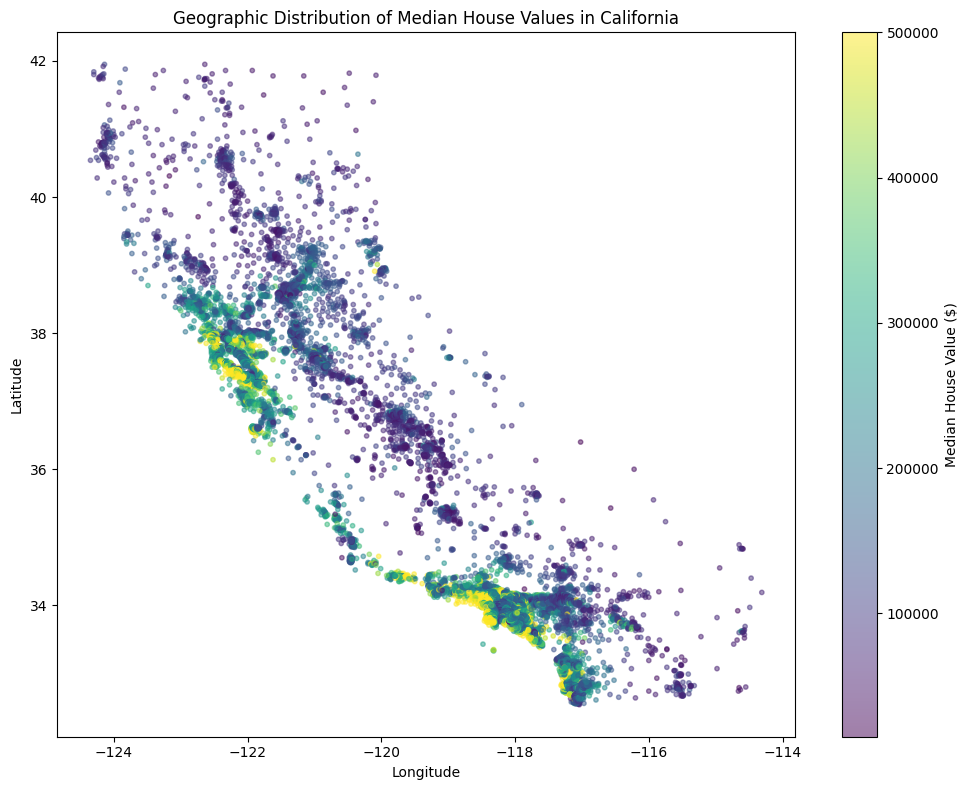

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')

plt.figure(figsize=(10, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['median_house_value'], 
                      cmap='viridis', 
                      alpha=0.5, 
                      s=10)

plt.colorbar(scatter, label='Median House Value ($)')
plt.title('Geographic Distribution of Median House Values in California')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('housing_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
Result: Success | Attempts: 1

Running task 18: [medium] Using the housing dataset, plot a histogram of median_income and add a solid vertical line at the median value labeled "median income". Show the legend on the plot.


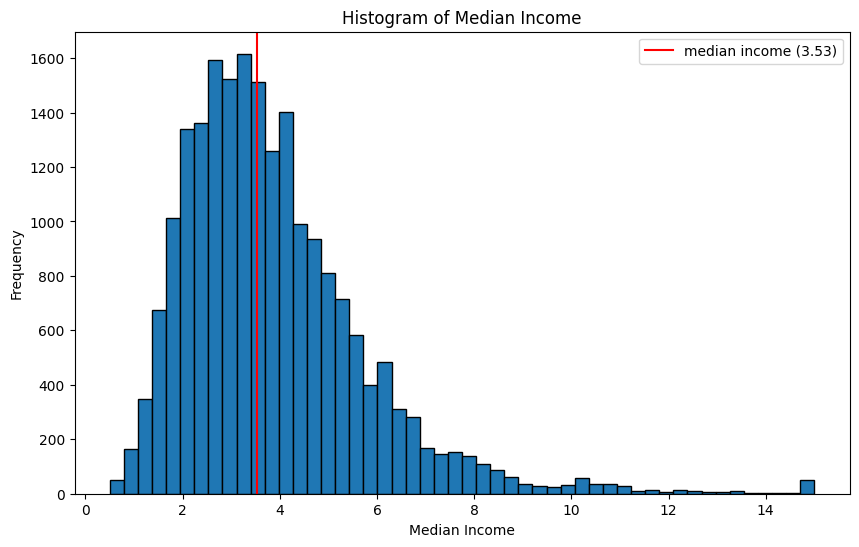

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')

median_value = df['median_income'].median()

plt.figure(figsize=(10, 6))
plt.hist(df['median_income'], bins=50, edgecolor='black')
plt.axvline(x=median_value, color='red', linestyle='-', label=f'median income ({median_value:.2f})')
plt.xlabel('Median Income')
plt.ylabel('Frequency')
plt.title('Histogram of Median Income')
plt.legend()
plt.show()
Result: Success | Attempts: 1

Running task 19: [medium] Using the housing dataset, compute the correlation matrix for numeric columns and plot it as a heatmap using matplotlib. Add a colorbar and readable tick labels.


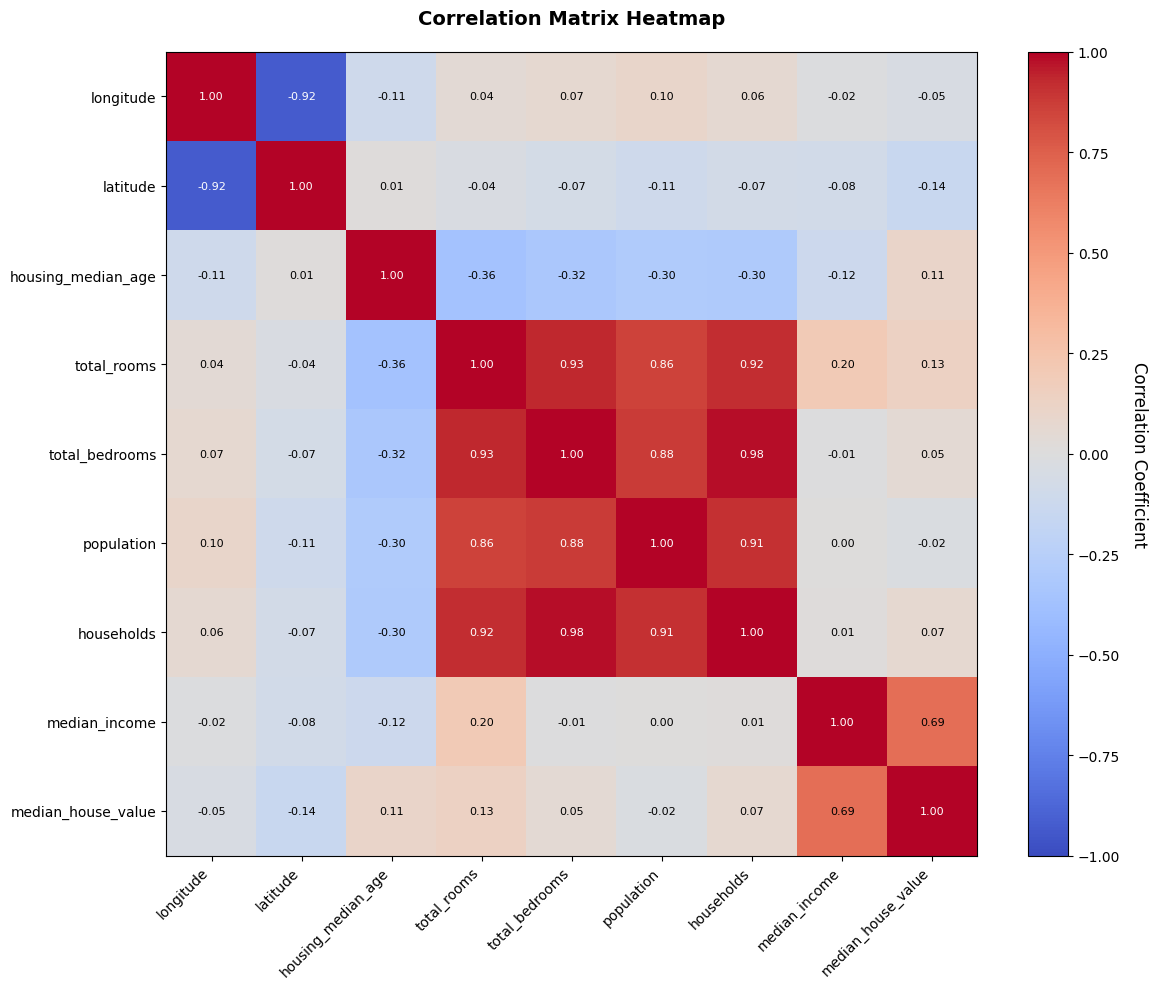

Correlation Matrix:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude                1.00     -0.92               -0.11         0.04   
latitude                -0.92      1.00                0.01        -0.04   
housing_median_age      -0.11      0.01                1.00        -0.36   
total_rooms              0.04     -0.04               -0.36         1.00   
total_bedrooms           0.07     -0.07               -0.32         0.93   
population               0.10     -0.11               -0.30         0.86   
households               0.06     -0.07               -0.30         0.92   
median_income           -0.02     -0.08               -0.12         0.20   
median_house_value      -0.05     -0.14                0.11         0.13   

                    total_bedrooms  population  households  median_income  \
longitude                     0.07        0.10        0.06          -0.02   
latitude                     -0.07       -0.11       -0.07       

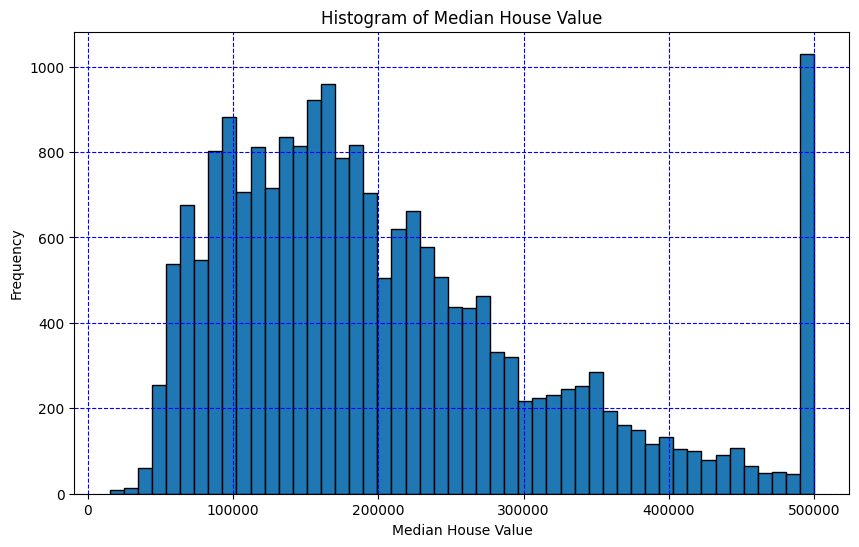

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')

plt.figure(figsize=(10, 6))
plt.hist(df['median_house_value'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Histogram of Median House Value')
plt.grid(True, color='blue', linestyle='--')
plt.show()
Result: Success | Attempts: 1

Running task 21: [medium] Using the Titanic dataset, make a donut chart showing the passenger count by Pclass. Use wedge width 0.4 and include class labels.


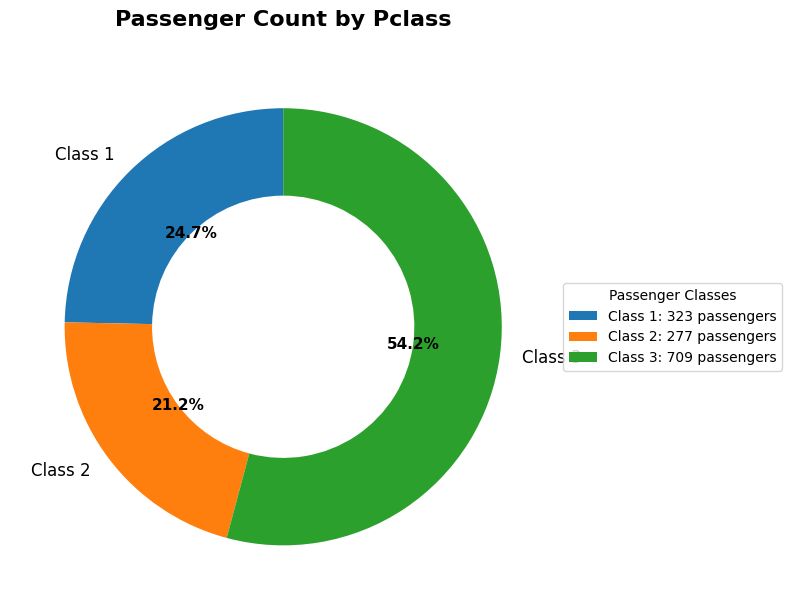

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('titanic.csv')

pclass_counts = df['Pclass'].value_counts().sort_index()

labels = [f'Class {cls}' for cls in pclass_counts.index]
sizes = pclass_counts.values

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(width=0.4)
)

for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax.set_title('Passenger Count by Pclass', fontsize=16, fontweight='bold', pad=20)

legend_labels = [f'Class {cls}: {count} passengers' for cls, count in zip(pclass_counts.index, sizes)]
ax.legend(wedges, legend_labels, title='Passenger Classes', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.savefig('donut_chart_pclass.png', bbox_inches='tight', dpi=150)
plt.show()
Result: S

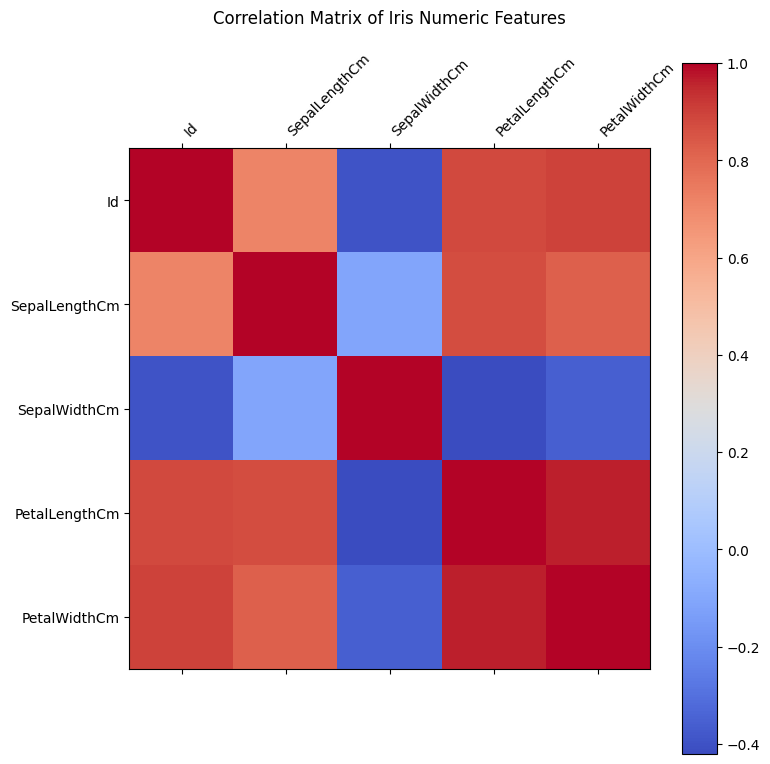

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Iris.csv')

numeric_df = df.select_dtypes(include='number')

corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr_matrix, cmap='coolwarm')
fig.colorbar(cax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)

plt.title('Correlation Matrix of Iris Numeric Features', pad=20)
plt.tight_layout()
plt.show()
Result: Success | Attempts: 1

Running task 23: [medium] Using the Iris dataset, plot SepalLengthCm over the row index with label "SepalLengthCm" and display a legend with font size 8.


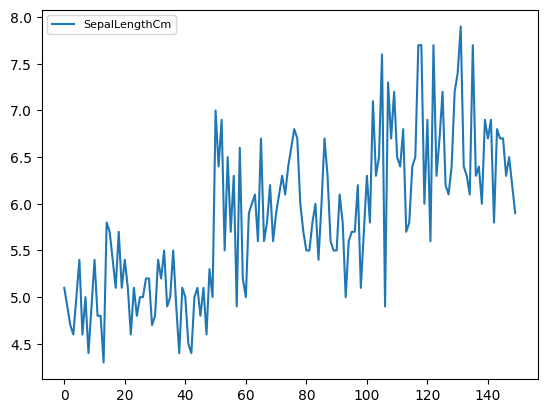

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Iris.csv')

plt.plot(df.index, df['SepalLengthCm'], label='SepalLengthCm')
plt.legend(fontsize=8)
plt.show()
Result: Success | Attempts: 1

Running task 24: [hard] Using the Iris dataset, encode the Species column using LabelEncoder, split the data into train and test sets with ratio 8:2, train a DecisionTreeClassifier, and output accuracy, classification report, and feature importances sorted in descending order.
Accuracy: 1.0000

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Feature Importances (s

<string>:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<string>:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perfor

Chosen cluster center index: 0

Top 50 samples closest to cluster center 0:

Row Index      Distance       
------------------------------
7678           0.168165       
7855           0.220118       
6926           0.232115       
11552          0.242042       
6482           0.250930       
6495           0.260941       
7883           0.292931       
6218           0.313374       
11560          0.325740       
7002           0.329223       
11669          0.330295       
6264           0.335606       
10174          0.337945       
11195          0.345955       
5609           0.353880       
5913           0.358502       
7673           0.365340       
6274           0.366530       
6861           0.367285       
6996           0.369918       
5976           0.370797       
11140          0.371252       
6191           0.379275       
7827           0.379747       
10233          0.383460       
6654           0.383734       
6318           0.384851       
7920           0.386688 

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Dataset shape: (1309, 28)

First few rows:
   Passengerid   Age     Fare  Sex  sibsp  zero  zero.1  zero.2  zero.3  \
0            1  22.0   7.2500    0      1     0       0       0       0   
1            2  38.0  71.2833    1      1     0       0       0       0   
2            3  26.0   7.9250    1      0     0       0       0       0   
3            4  35.0  53.1000    1      1     0       0       0       0   
4            5  35.0   8.0500    0      0     0       0       0       0   

   zero.4  ...  zero.12  zero.13  zero.14  Pclass  zero.15  zero.16  Embarked  \
0       0  ...        0        0        0       3        0        0       2.0   
1       0  ...        0        0        0       1        0        0       0.0   
2       0  ...        0        0        0       3        0        0       2.0   
3       0  ...        0        0        0       1        0        0       2.0   
4       0  ...        0        0        0       3        0        0       2.0   

   zero.17  zero.18

In [9]:
import json
import pandas as pd

# Load benchmark tasks
with open('benchmarks/prompts.json', 'r') as f:
    benchmarks = json.load(f)['benchmarks']

# Dataset path mapping
dataset_paths = {
    "Iris.csv": "Iris.csv",
    "Titanic.csv": "titanic.csv",
    "housing.csv": "housing.csv"
}

# Run all benchmark tasks with self-healing pipeline
results = []

for task in benchmarks:
    print(f"\nRunning task {task['id']}: [{task['difficulty']}] {task['prompt']}")

    dataset_path = dataset_paths[task['dataset']]
    result = run_pipeline(task['prompt'], dataset_path)

    results.append({
        "id": task['id'],
        "dataset": task['dataset'],
        "difficulty": task['difficulty'],
        "category": task['category'],
        "prompt": task['prompt'],
        "success": result['success'],
        "attempts": result['attempts']
    })

    print(f"Result: {'Success' if result['success'] else 'Failed'} | Attempts: {result['attempts']}")

# Save results to a DataFrame and display summary
df_results = pd.DataFrame(results)
print("\n===== BENCHMARK RESULTS =====")
print(df_results[['id', 'difficulty', 'category', 'success', 'attempts']])
print(f"\nOverall success rate: {df_results['success'].mean()*100:.1f}%")
print(f"Easy success rate: {df_results[df_results['difficulty']=='easy']['success'].mean()*100:.1f}%")
print(f"Medium success rate: {df_results[df_results['difficulty']=='medium']['success'].mean()*100:.1f}%")
print(f"Hard success rate: {df_results[df_results['difficulty']=='hard']['success'].mean()*100:.1f}%")

# Save results to CSV
df_results.to_csv('benchmark_results_selfhealing.csv', index=False)
print("\nResults saved to benchmark_results_selfhealing.csv")